# Solafune 降水ナウキャスト EDA

このNotebookでは次を確認します。

- train / evaluation のメタデータ分布
- `unique_id`、目的変数ファイル名、観測系列の重複
- 衛星・地域・日時ごとのサンプル偏り
- GPM IMERG降水量の分布、ゼロ比率、外れ値
- 生値と `log1p` 変換後の正規性（ヒストグラム、Q-Q plot、正規性検定）

> 降水量は通常、ゼロが多く右裾の長い分布です。正規分布への適合だけでなく、ゼロ比率と豪雨側の裾も確認します。

In [1]:
from pathlib import Path
import ast
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import seaborn as sns
from scipy import stats
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 30)

RANDOM_SEED = 42
TARGET_FILE_SAMPLE = 2_000   # None にすると全GPMファイルを読む
PIXELS_PER_FILE = 500        # 各GPM画像から抽出する画素数
QQ_SAMPLE_SIZE = 20_000

candidates = [Path.cwd(), Path.cwd().parent]
ROOT = next((p for p in candidates if (p / 'train_dataset').is_dir()), None)
if ROOT is None:
    raise FileNotFoundError('train_dataset/ が見つかりません。')

TRAIN_DIR = ROOT / 'train_dataset'
EVAL_DIR = ROOT / 'evaluation_dataset'
GPM_DIR = TRAIN_DIR / 'gpm_imerg'
OUTPUT_DIR = ROOT / 'outputs' / 'eda'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Workspace: {ROOT}')

Workspace: /Users/shionsuio/solafune-workspace


## 1. メタデータ読み込み

In [2]:
train = pd.read_csv(TRAIN_DIR / 'train_dataset.csv')
evaluation = pd.read_csv(EVAL_DIR / 'evaluation_target.csv')

for df in (train, evaluation):
    df['datetime'] = pd.to_datetime(df['datetime'])
    df['year_month'] = df['datetime'].dt.to_period('M').astype(str)
    df['hour'] = df['datetime'].dt.hour
    df['observation_files'] = df['last_30_minutes_observation_filename'].map(ast.literal_eval)
    df['observation_sequence'] = df['observation_files'].map(tuple)

summary = pd.DataFrame({
    'rows': [len(train), len(evaluation)],
    'locations': [train['name_location'].nunique(), evaluation['name_location'].nunique()],
    'satellites': [train['satellite_target'].nunique(), evaluation['satellite_target'].nunique()],
    'start': [train['datetime'].min(), evaluation['datetime'].min()],
    'end': [train['datetime'].max(), evaluation['datetime'].max()],
    'missing_cells': [int(train.isna().sum().sum()), int(evaluation.isna().sum().sum())],
}, index=['train', 'evaluation'])
display(summary)
display(train.head(3))

,rows,locations,satellites,start,end,missing_cells
train,40686,20,3,2023-01-01,2026-01-31 21:30:00,0
evaluation,29090,18,3,2023-01-01,2026-01-31 21:30:00,0


,unique_id,name_location,satellite_target,datetime,last_30_minutes_observation_filename,gpm_imerg_filename,year_month,hour,observation_files,observation_sequence
0,c901-207d,aceh,himawari,2023-01-01 00:00:00,"['train_aceh_Himawari_20221231_2330.tif', 'tra...",train_aceh_GPM_IMERG_2023-01-01_00-00-00.tif,2023-01,0,"[train_aceh_Himawari_20221231_2330.tif, train_...","(train_aceh_Himawari_20221231_2330.tif, train_..."
1,3311-9497,aceh,himawari,2023-01-01 00:30:00,"['train_aceh_Himawari_20230101_0000.tif', 'tra...",train_aceh_GPM_IMERG_2023-01-01_00-30-00.tif,2023-01,0,"[train_aceh_Himawari_20230101_0000.tif, train_...","(train_aceh_Himawari_20230101_0000.tif, train_..."
2,ae46-e82d,aceh,himawari,2023-01-01 01:00:00,"['train_aceh_Himawari_20230101_0030.tif', 'tra...",train_aceh_GPM_IMERG_2023-01-01_01-00-00.tif,2023-01,1,"[train_aceh_Himawari_20230101_0030.tif, train_...","(train_aceh_Himawari_20230101_0030.tif, train_..."


## 2. ID・ファイル・観測系列の重複確認

`unique_id`だけでなく、同じ地域・時刻・衛星の重複、同じ目的変数ファイル、同一の3枚観測系列も確認します。

In [3]:
def duplicate_report(df, name):
    keys = {
        'unique_id': ['unique_id'],
        'location + satellite + datetime': ['name_location', 'satellite_target', 'datetime'],
        'gpm_imerg_filename': ['gpm_imerg_filename'],
        '3-image observation sequence': ['observation_sequence'],
    }
    rows = []
    for label, columns in keys.items():
        mask = df.duplicated(columns, keep=False)
        rows.append({
            'dataset': name,
            'key': label,
            'duplicated_rows': int(mask.sum()),
            'duplicated_groups': int(df.loc[mask].groupby(columns, dropna=False).ngroups) if mask.any() else 0,
        })
    return pd.DataFrame(rows)

duplicates = pd.concat([
    duplicate_report(train, 'train'),
    duplicate_report(evaluation, 'evaluation'),
], ignore_index=True)
display(duplicates)

overlap_ids = set(train['unique_id']) & set(evaluation['unique_id'])
overlap_targets = set(train['gpm_imerg_filename']) & set(evaluation['gpm_imerg_filename'])
print(f'train/evaluation unique_id overlap: {len(overlap_ids):,}')
print(f'train/evaluation target filename overlap: {len(overlap_targets):,}')

# 個別の衛星観測TIFが何サンプルで再利用されるか
observation_usage = (
    train[['unique_id', 'observation_files']]
    .explode('observation_files')
    .groupby('observation_files')['unique_id']
    .nunique()
    .sort_values(ascending=False)
)
print(f'複数サンプルで使われる観測画像: {(observation_usage > 1).sum():,}')
display(observation_usage.head(10).rename('sample_count').to_frame())

duplicates.to_csv(OUTPUT_DIR / 'duplicate_report.csv', index=False)

,dataset,key,duplicated_rows,duplicated_groups
0,train,unique_id,0,0
1,train,location + satellite + datetime,0,0
2,train,gpm_imerg_filename,0,0
3,train,3-image observation sequence,235,1
4,evaluation,unique_id,0,0
5,evaluation,location + satellite + datetime,0,0
6,evaluation,gpm_imerg_filename,0,0
7,evaluation,3-image observation sequence,29,1


train/evaluation unique_id overlap: 0
train/evaluation target filename overlap: 0
複数サンプルで使われる観測画像: 0


,sample_count
observation_files,
train_aceh_Himawari_20221231_2330.tif,1
train_france_Meteosat_20250921_0510.tif,1
train_france_Meteosat_20250921_0710.tif,1
train_france_Meteosat_20250921_0700.tif,1
train_france_Meteosat_20250921_0650.tif,1
train_france_Meteosat_20250921_0640.tif,1
train_france_Meteosat_20250921_0630.tif,1
train_france_Meteosat_20250921_0620.tif,1
train_france_Meteosat_20250921_0610.tif,1


In [4]:
# 重複が存在する場合の具体例
duplicate_examples = train[train.duplicated('unique_id', keep=False)].sort_values('unique_id')
if len(duplicate_examples):
    display(duplicate_examples.head(20))
else:
    print('trainのunique_id重複はありません。')

trainのunique_id重複はありません。


## 3. カテゴリ・時系列分布

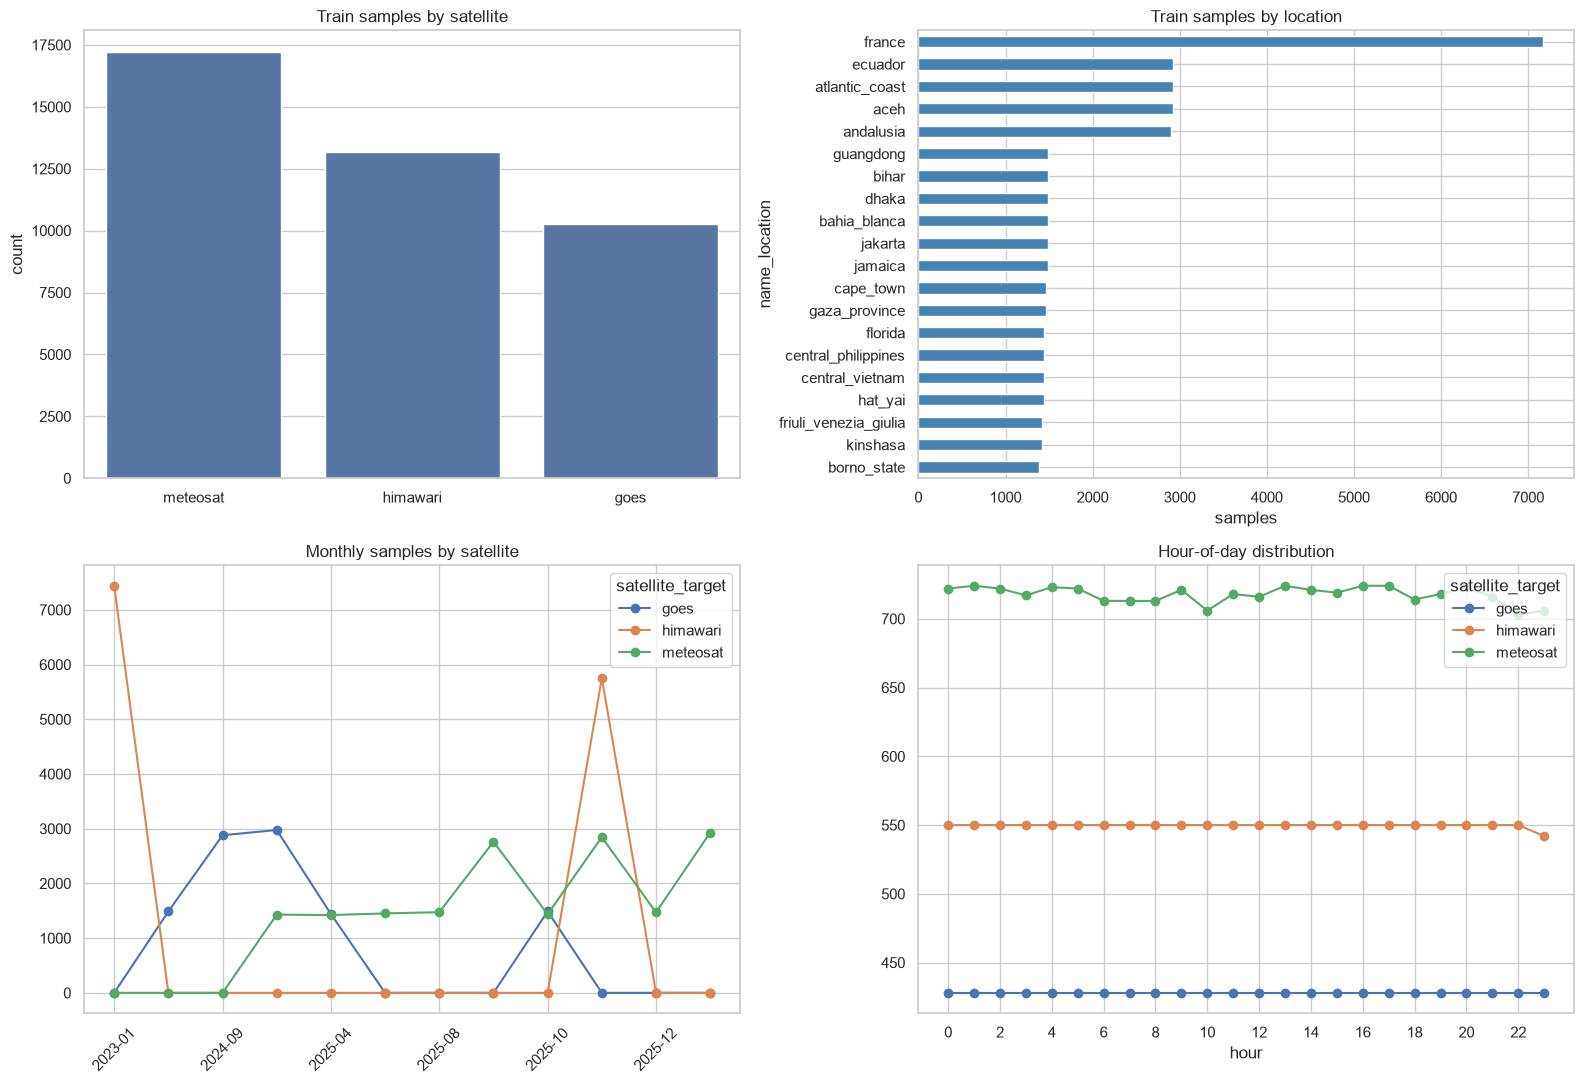

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

sns.countplot(data=train, x='satellite_target', order=train['satellite_target'].value_counts().index, ax=axes[0, 0])
axes[0, 0].set_title('Train samples by satellite')
axes[0, 0].set_xlabel('')

location_counts = train['name_location'].value_counts().sort_values()
location_counts.plot.barh(ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title('Train samples by location')
axes[0, 1].set_xlabel('samples')

monthly = train.groupby(['year_month', 'satellite_target']).size().unstack(fill_value=0)
monthly.plot(ax=axes[1, 0], marker='o')
axes[1, 0].set_title('Monthly samples by satellite')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].set_xlabel('')

hourly = train.groupby(['hour', 'satellite_target']).size().unstack(fill_value=0)
hourly.plot(ax=axes[1, 1], marker='o')
axes[1, 1].set_title('Hour-of-day distribution')
axes[1, 1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

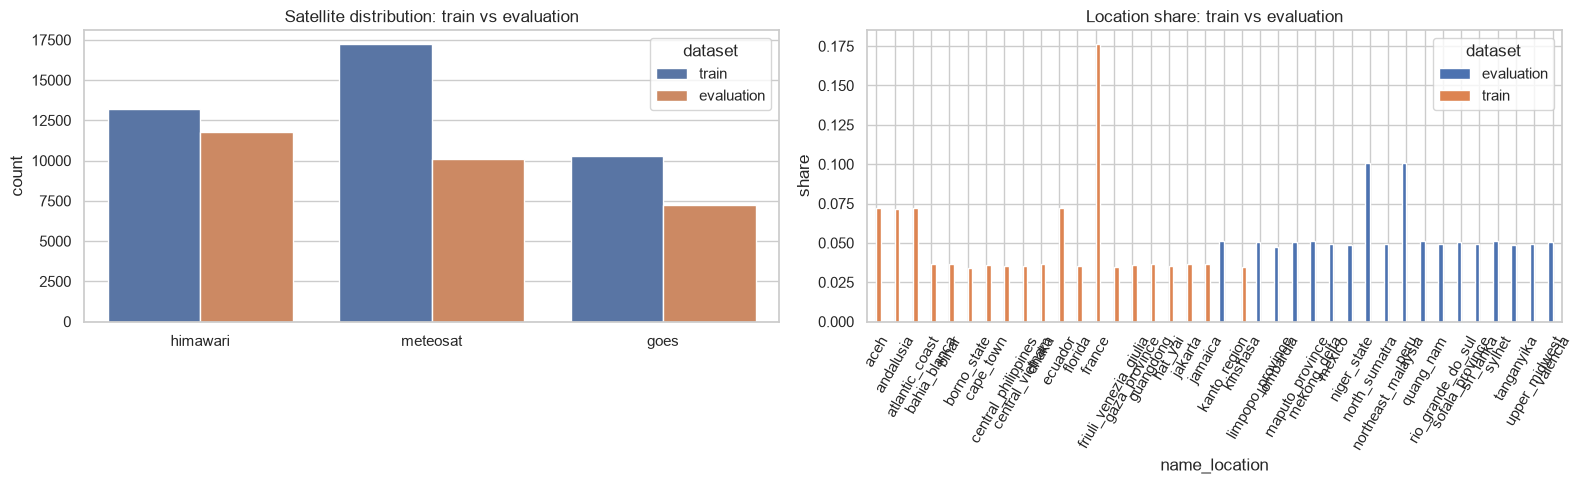

In [6]:
# trainとevaluationのカテゴリ構成比較
comparison = pd.concat([
    train.assign(dataset='train'),
    evaluation.assign(dataset='evaluation'),
])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.countplot(data=comparison, x='satellite_target', hue='dataset', ax=axes[0])
axes[0].set_title('Satellite distribution: train vs evaluation')
axes[0].set_xlabel('')

location_share = pd.crosstab(comparison['name_location'], comparison['dataset'], normalize='columns')
location_share.plot.bar(ax=axes[1])
axes[1].set_title('Location share: train vs evaluation')
axes[1].set_ylabel('share')
axes[1].tick_params(axis='x', rotation=60)
plt.tight_layout()
plt.show()

## 4. GPM IMERG目的変数の分布

ファイル読み込み時間を抑えるため、デフォルトでは2,000ファイルを無作為抽出します。全件確認する場合は先頭セルの `TARGET_FILE_SAMPLE = None` に変更してください。

In [7]:
rng = np.random.default_rng(RANDOM_SEED)
target_meta = train[['unique_id', 'name_location', 'satellite_target', 'datetime', 'gpm_imerg_filename']].copy()
if TARGET_FILE_SAMPLE is not None and TARGET_FILE_SAMPLE < len(target_meta):
    target_meta = target_meta.sample(TARGET_FILE_SAMPLE, random_state=RANDOM_SEED)

file_stats = []
pixel_samples = []
missing_targets = []

for row in tqdm(target_meta.itertuples(index=False), total=len(target_meta), desc='Reading GPM targets'):
    path = GPM_DIR / row.gpm_imerg_filename
    if not path.is_file():
        missing_targets.append(str(path))
        continue
    with rasterio.open(path) as src:
        values = src.read(1).astype(np.float32)
        if src.nodata is not None:
            values[values == src.nodata] = np.nan
    valid = values[np.isfinite(values)]
    if not len(valid):
        continue
    positive = valid[valid > 0]
    take = min(PIXELS_PER_FILE, len(valid))
    pixel_samples.append(rng.choice(valid, size=take, replace=False))
    file_stats.append({
        'unique_id': row.unique_id,
        'name_location': row.name_location,
        'satellite_target': row.satellite_target,
        'datetime': row.datetime,
        'mean': float(valid.mean()),
        'std': float(valid.std()),
        'max': float(valid.max()),
        'p95': float(np.quantile(valid, 0.95)),
        'positive_ratio': float((valid > 0).mean()),
        'heavy_rain_ratio_10': float((valid >= 10).mean()),
        'positive_mean': float(positive.mean()) if len(positive) else 0.0,
    })

target_stats = pd.DataFrame(file_stats)
pixels = np.concatenate(pixel_samples) if pixel_samples else np.array([], dtype=np.float32)
positive_pixels = pixels[pixels > 0]

print(f'Files analyzed: {len(target_stats):,}')
print(f'Pixels sampled: {len(pixels):,}')
print(f'Missing targets: {len(missing_targets):,}')
print(f'Zero ratio: {(pixels == 0).mean():.2%}')
display(target_stats.describe(percentiles=[.5, .9, .95, .99]).T)
target_stats.to_csv(OUTPUT_DIR / 'gpm_file_statistics.csv', index=False)

Reading GPM targets:   0%|          | 0/2000 [00:00<?, ?it/s]

Files analyzed: 2,000
Pixels sampled: 1,000,000
Missing targets: 0
Zero ratio: 82.98%


,count,mean,min,50%,90%,95%,99%,max,std
datetime,2000,2025-02-03 15:07:57.000000256,2023-01-01 00:00:00,2025-07-22 09:45:00,2025-12-13 20:30:00,2026-01-11 18:13:30,2026-01-26 17:07:12,2026-01-31 19:00:00,NaN
mean,2000.0,0.250737,0.0,0.044393,0.656513,1.110432,3.241754,6.736544,0.573853
std,2000.0,0.620553,0.0,0.244157,1.649823,2.334493,5.085442,9.667865,0.985632
max,2000.0,7.417998,0.0,3.67,19.782999,27.710499,42.191199,77.639999,9.738669
p95,2000.0,1.225836,0.0,0.15,3.652,5.3505,13.0934,26.769999,2.512952
positive_ratio,2000.0,0.170086,0.0,0.084771,0.474777,0.618798,0.841802,0.994051,0.205209
heavy_rain_ratio_10,2000.0,0.003192,0.0,0.0,0.004759,0.012522,0.090428,0.216538,0.014472
positive_mean,2000.0,0.780219,0.0,0.519302,1.811838,2.396833,4.582906,7.612216,0.890605


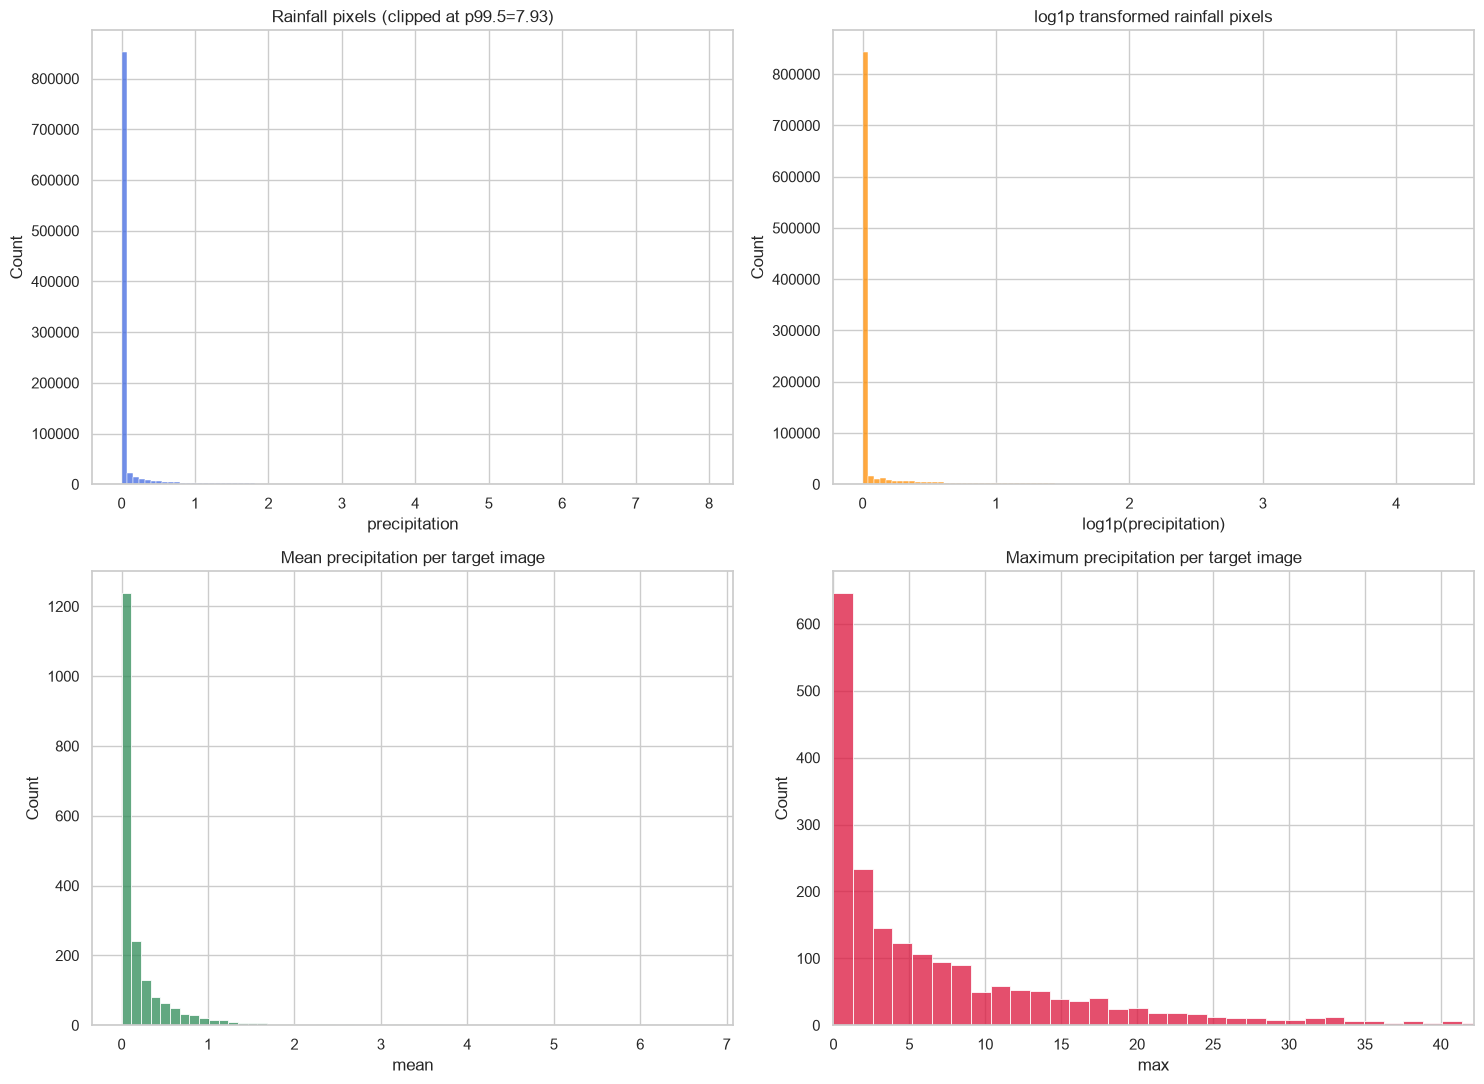

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

upper = np.quantile(pixels, 0.995)
sns.histplot(pixels[pixels <= upper], bins=100, ax=axes[0, 0], color='royalblue')
axes[0, 0].set_title(f'Rainfall pixels (clipped at p99.5={upper:.2f})')
axes[0, 0].set_xlabel('precipitation')

sns.histplot(np.log1p(pixels), bins=100, ax=axes[0, 1], color='darkorange')
axes[0, 1].set_title('log1p transformed rainfall pixels')
axes[0, 1].set_xlabel('log1p(precipitation)')

sns.histplot(target_stats['mean'], bins=60, ax=axes[1, 0], color='seagreen')
axes[1, 0].set_title('Mean precipitation per target image')

sns.histplot(target_stats['max'], bins=60, ax=axes[1, 1], color='crimson')
axes[1, 1].set_title('Maximum precipitation per target image')
axes[1, 1].set_xlim(0, target_stats['max'].quantile(.99))

plt.tight_layout()
plt.show()

## 5. 正規性の確認

大標本では正規性検定が非常に敏感なので、p値だけでなくQ-Q plot・歪度・尖度も合わせて判断します。降水量のようなゼロ過剰データでは、正規分布を仮定しない損失関数や `log1p` 変換も候補です。

,distribution,n,mean,std,skewness,excess_kurtosis,normaltest_K2,normaltest_p
0,raw,50000,0.252516,1.324631,12.698730,251.124588,88526.046875,0.0
1,log1p,50000,0.107167,0.354826,4.404856,22.288586,44371.718750,0.0


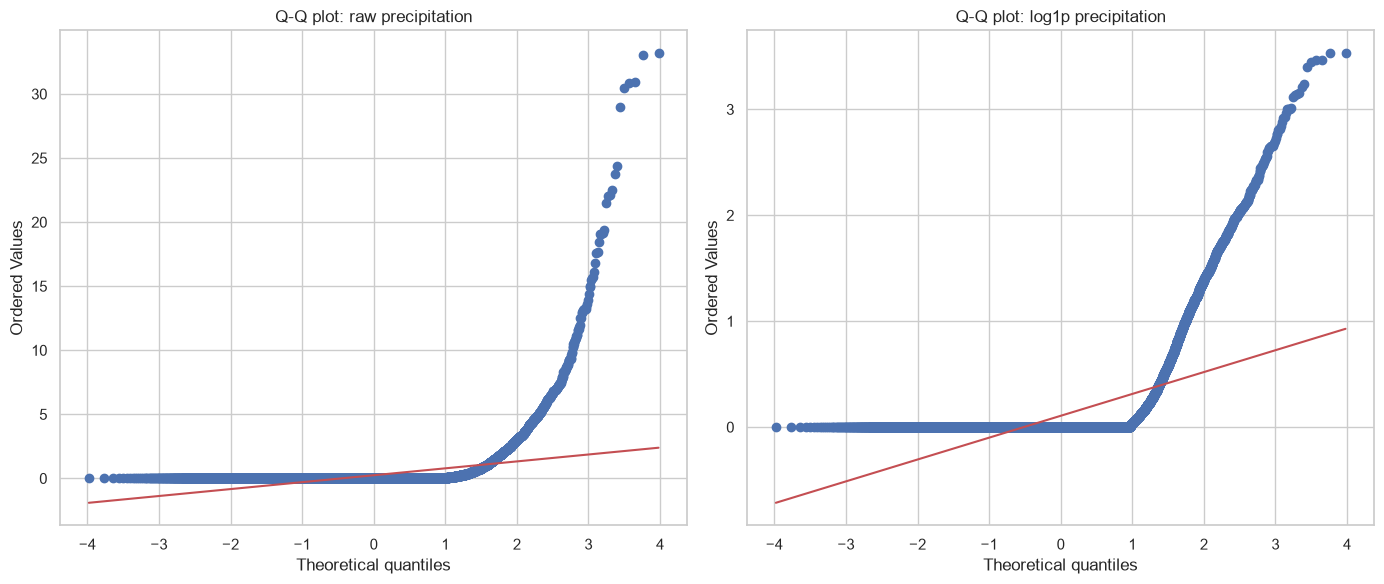

In [9]:
normality_rng = np.random.default_rng(RANDOM_SEED)
normality_n = min(50_000, len(pixels))
normality_raw = normality_rng.choice(pixels, normality_n, replace=False)
normality_log = np.log1p(normality_raw)

def distribution_metrics(values, label):
    k2, p_value = stats.normaltest(values)
    return {
        'distribution': label,
        'n': len(values),
        'mean': values.mean(),
        'std': values.std(),
        'skewness': stats.skew(values),
        'excess_kurtosis': stats.kurtosis(values),
        'normaltest_K2': k2,
        'normaltest_p': p_value,
    }

normality = pd.DataFrame([
    distribution_metrics(normality_raw, 'raw'),
    distribution_metrics(normality_log, 'log1p'),
])
display(normality)

qq_n = min(QQ_SAMPLE_SIZE, len(normality_raw))
qq_idx = normality_rng.choice(len(normality_raw), qq_n, replace=False)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
stats.probplot(normality_raw[qq_idx], dist='norm', plot=axes[0])
axes[0].set_title('Q-Q plot: raw precipitation')
stats.probplot(normality_log[qq_idx], dist='norm', plot=axes[1])
axes[1].set_title('Q-Q plot: log1p precipitation')
plt.tight_layout()
plt.show()

normality.to_csv(OUTPUT_DIR / 'normality_metrics.csv', index=False)

## 6. 衛星・地域別の目的変数分布

特定の衛星や地域に強雨が偏る場合、ランダム分割ではなく地域・時系列を考慮した検証が必要です。

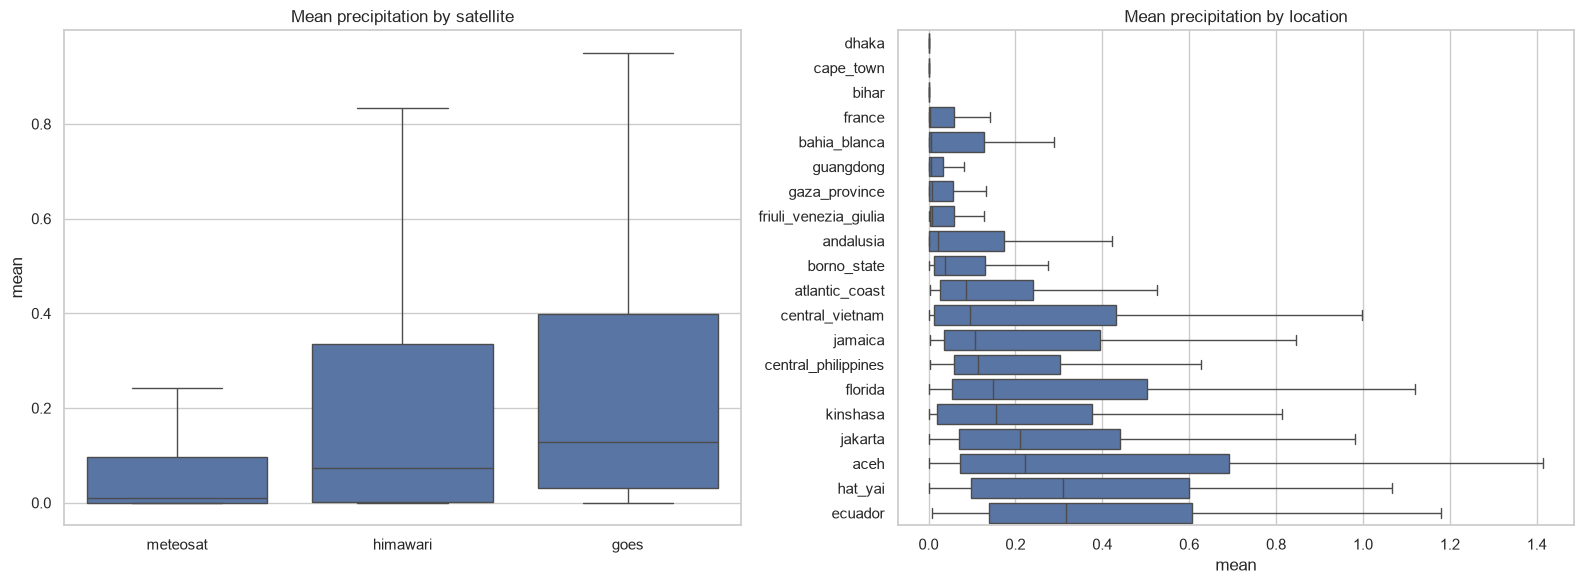

,samples,mean_rain,median_rain,mean_positive_ratio,p99_max
satellite_target,,,,,
himawari,632,0.371052,0.074090,0.213192,51.744399
goes,521,0.341273,0.128061,0.237651,42.201998
meteosat,847,0.105273,0.009607,0.096362,33.664201


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=target_stats, x='satellite_target', y='mean', showfliers=False, ax=axes[0])
axes[0].set_title('Mean precipitation by satellite')
axes[0].set_xlabel('')

location_order = target_stats.groupby('name_location')['mean'].median().sort_values().index
sns.boxplot(data=target_stats, y='name_location', x='mean', order=location_order, showfliers=False, ax=axes[1])
axes[1].set_title('Mean precipitation by location')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

display(
    target_stats.groupby('satellite_target')
    .agg(samples=('unique_id', 'size'), mean_rain=('mean', 'mean'), median_rain=('mean', 'median'),
         mean_positive_ratio=('positive_ratio', 'mean'), p99_max=('max', lambda x: x.quantile(.99)))
    .sort_values('mean_rain', ascending=False)
)

## 7. モデリング上の確認ポイント

実行結果を踏まえて、以下を判断します。

- `unique_id`や地域・時刻キーに重複があれば、train/validation間のリークを防ぐ
- 降水ゼロが多ければ、雨の有無と雨量を分ける2段階モデルも検討する
- 生値が強く右に歪む場合は、Huber loss、加重MSE、`log1p`目的変数を比較する
- 豪雨側のサンプルが少なければ、降水量別サンプリングや重み付けを検討する
- 衛星・地域ごとの分布差が大きければ、衛星ID条件付けやGroup splitを使う

集計CSVは `outputs/eda/` に保存されます。

In [11]:
train_locs = set(train['name_location'].unique())
eval_locs  = set(evaluation['name_location'].unique())

print(f"train のみ:       {sorted(train_locs - eval_locs)}")
print(f"evaluation のみ:  {sorted(eval_locs - train_locs)}")
print(f"共通:             {len(train_locs & eval_locs)} 地域")


train のみ:       ['aceh', 'andalusia', 'atlantic_coast', 'bahia_blanca', 'bihar', 'borno_state', 'cape_town', 'central_philippines', 'central_vietnam', 'dhaka', 'ecuador', 'florida', 'france', 'friuli_venezia_giulia', 'gaza_province', 'guangdong', 'hat_yai', 'jakarta', 'jamaica', 'kinshasa']
evaluation のみ:  ['kanto_region', 'limpopo_province', 'lombardia', 'maputo_province', 'mekong_delta', 'mexico', 'niger_state', 'north_sumatra', 'northeast_malaysia', 'peru', 'quang_nam', 'rio_grande_do_sul', 'sofala_province', 'sri_lanka', 'sylhet', 'tanganyika', 'upper_midwest', 'valencia']
共通:             0 地域


## 8. 季節・時刻の周期特徴

`datetime`から以下の4特徴を作ります。すべて配布CSV由来で、外部データは使用しません。

- `month_sin`, `month_cos`: 12月と1月が近くなる月周期表現
- `hour_sin`, `hour_cos`: 23時と0時が近くなる時刻周期表現

> GeoTIFFも確認しましたが、CRSは`None`、transformは単位行列で、実際の緯度経度は格納されていません。そのため座標特徴はここでは作りません。また、時刻がUTCの場合は`hour`を現地時刻とは解釈できない点に注意します。

In [12]:
def add_cyclical_time_features(df):
    result = df.copy()
    dt = pd.to_datetime(result['datetime'])
    month = dt.dt.month
    hour = dt.dt.hour + dt.dt.minute / 60
    result['month'] = month
    result['hour_float'] = hour
    result['month_sin'] = np.sin(2 * np.pi * (month - 1) / 12)
    result['month_cos'] = np.cos(2 * np.pi * (month - 1) / 12)
    result['hour_sin'] = np.sin(2 * np.pi * hour / 24)
    result['hour_cos'] = np.cos(2 * np.pi * hour / 24)
    return result

train_time = add_cyclical_time_features(train)
eval_time = add_cyclical_time_features(evaluation)

feature_cols = ['month_sin', 'month_cos', 'hour_sin', 'hour_cos']
display(train_time[['datetime'] + feature_cols].head())

time_feature_summary = pd.concat({
    'train': train_time[feature_cols].describe().T,
    'evaluation': eval_time[feature_cols].describe().T,
}, axis=1)
display(time_feature_summary)

,datetime,month_sin,month_cos,hour_sin,hour_cos
0,2023-01-01 00:00:00,0.0,1.0,0.000000,1.000000
1,2023-01-01 00:30:00,0.0,1.0,0.130526,0.991445
2,2023-01-01 01:00:00,0.0,1.0,0.258819,0.965926
3,2023-01-01 01:30:00,0.0,1.0,0.382683,0.923880
4,2023-01-01 02:00:00,0.0,1.0,0.500000,0.866025


train                                                       \
             count      mean       std  min           25%           50%   
month_sin  40686.0 -0.265361  0.665399 -1.0 -8.660254e-01 -5.000000e-01   
month_cos  40686.0  0.277906  0.640013 -1.0 -1.836970e-16  5.000000e-01   
hour_sin   40686.0 -0.000156  0.707338 -1.0 -7.071068e-01  1.224647e-16   
hour_cos   40686.0 -0.000333  0.706892 -1.0 -7.071068e-01  6.123234e-17   

                         evaluation                                \
                75%  max      count      mean       std       min   
month_sin  0.000000  1.0    29090.0  0.095690  0.640417 -0.866025   
month_cos  1.000000  1.0    29090.0  0.440853  0.621599 -0.866025   
hour_sin   0.707107  1.0    29090.0 -0.000622  0.707462 -1.000000   
hour_cos   0.707107  1.0    29090.0 -0.000301  0.706775 -1.000000   

                                                      
                    25%           50%       75%  max  
month_sin  0.000000e+00  0.000000e+00  0.500000  1.0  
month_cos  6.123234e-17  5.000000e-01  1.000000  1.0  
hour_sin  -7.071068e-01  1.224647e-16  0.707107  1.0  
hour_cos  -7.071068e-01  6.123234e-17  0.707107  1.0

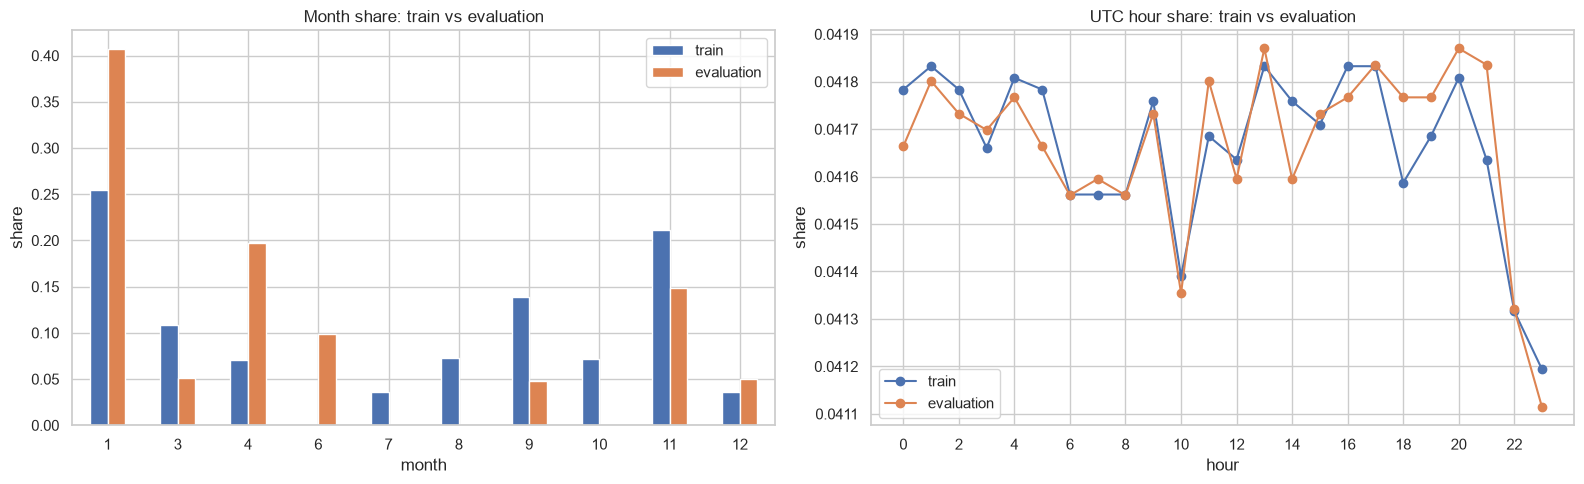

,train,evaluation
month,,
1,0.2549,0.4068
3,0.1083,0.0512
4,0.0703,0.1967
6,0.0000,0.0990
7,0.0357,0.0000
8,0.0728,0.0000
9,0.1387,0.0475
10,0.0719,0.0000
11,0.2113,0.1483


In [13]:
# train/evaluationで月・時刻の構成がどれだけ異なるか
month_share = pd.concat({
    'train': train_time['month'].value_counts(normalize=True),
    'evaluation': eval_time['month'].value_counts(normalize=True),
}, axis=1).fillna(0).sort_index()

hour_share = pd.concat({
    'train': train_time['datetime'].dt.hour.value_counts(normalize=True),
    'evaluation': eval_time['datetime'].dt.hour.value_counts(normalize=True),
}, axis=1).fillna(0).sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
month_share.plot.bar(ax=axes[0])
axes[0].set_title('Month share: train vs evaluation')
axes[0].set_xlabel('month')
axes[0].set_ylabel('share')
axes[0].tick_params(axis='x', rotation=0)

hour_share.plot(ax=axes[1], marker='o')
axes[1].set_title('UTC hour share: train vs evaluation')
axes[1].set_xlabel('hour')
axes[1].set_ylabel('share')
axes[1].set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

display(month_share.round(4))

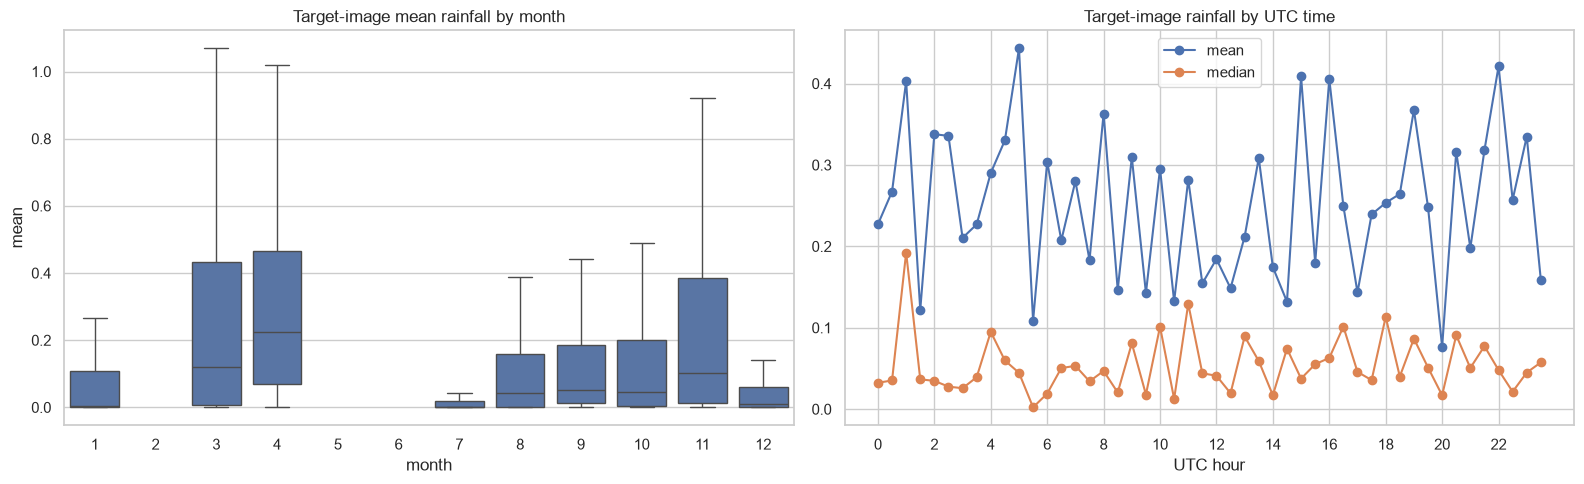

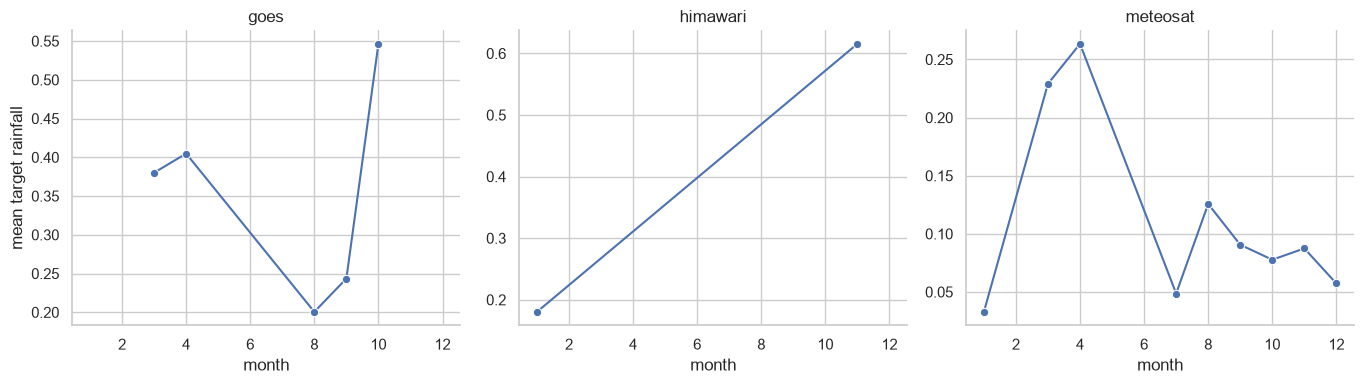

,satellite_target,month,count,mean,median
0,goes,3,151,0.380077,0.136151
1,goes,4,68,0.404798,0.279004
2,goes,8,78,0.200485,0.087948
3,goes,9,149,0.243421,0.101112
4,goes,10,75,0.546371,0.107055
5,himawari,1,355,0.180313,0.009518
6,himawari,11,277,0.615500,0.161672
7,meteosat,1,148,0.032847,0.000592
8,meteosat,3,76,0.229107,0.071642
9,meteosat,4,82,0.263414,0.155033


In [14]:
# 目的変数統計と時間特徴を結合
target_time = add_cyclical_time_features(target_stats)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
month_order = list(range(1, 13))
sns.boxplot(data=target_time, x='month', y='mean', order=month_order,
            showfliers=False, ax=axes[0])
axes[0].set_title('Target-image mean rainfall by month')

hourly_target = target_time.groupby('hour_float')['mean'].agg(['mean', 'median'])
hourly_target.plot(ax=axes[1], marker='o')
axes[1].set_title('Target-image rainfall by UTC time')
axes[1].set_xlabel('UTC hour')
axes[1].set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

# 月差とlocation差が混ざるため、衛星別にも表示する
monthly_satellite = (
    target_time.groupby(['satellite_target', 'month'])['mean']
    .agg(['count', 'mean', 'median'])
    .reset_index()
)
g = sns.relplot(
    data=monthly_satellite, x='month', y='mean', col='satellite_target',
    kind='line', marker='o', facet_kws={'sharey': False}, height=4, aspect=1.15
)
g.set_axis_labels('month', 'mean target rainfall')
g.set_titles('{col_name}')
plt.show()

display(monthly_satellite)

,mean,max,positive_ratio
month_sin,-0.040276,-0.043966,-0.078749
month_cos,-0.133310,-0.163072,-0.108282
hour_sin,-0.034235,-0.048420,-0.022928
hour_cos,0.024900,0.025720,0.037133


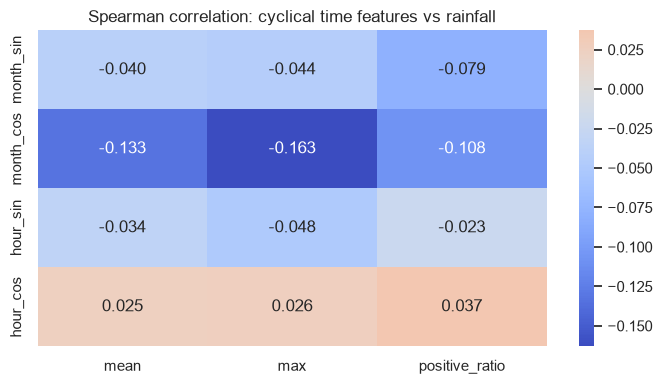

In [15]:
# 単純相関は非線形な周期関係を完全には表せませんが、参考値として確認
time_correlations = (
    target_time[feature_cols + ['mean', 'max', 'positive_ratio']]
    .corr(method='spearman')
    .loc[feature_cols, ['mean', 'max', 'positive_ratio']]
)
display(time_correlations)

plt.figure(figsize=(7, 4))
sns.heatmap(time_correlations, annot=True, fmt='.3f', cmap='coolwarm', center=0)
plt.title('Spearman correlation: cyclical time features vs rainfall')
plt.tight_layout()
plt.show()

month_share.to_csv(OUTPUT_DIR / 'month_share_train_vs_eval.csv')
hour_share.to_csv(OUTPUT_DIR / 'hour_share_train_vs_eval.csv')
monthly_satellite.to_csv(OUTPUT_DIR / 'monthly_target_by_satellite.csv', index=False)
time_correlations.to_csv(OUTPUT_DIR / 'time_feature_correlations.csv')